In [ ]:
## Weekly MiniProject
# Project Description

# Using the AAPL (Apple Inc.) stock dataset, conduct the following analyses:


# Initial Data Exploration

#     Load the dataset using Pandas. Check for null values and understand data types.
import pandas as pd
import numpy as np

df_raw = pd.read_csv('ApplePrices.csv')
df = df_raw.copy()
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,02/01/1981,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1,05/01/1981,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
2,06/01/1981,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
3,07/01/1981,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
4,08/01/1981,0.135603,0.135603,0.135045,0.135045,0.105085,39827200


In [4]:
df.shape

(10608, 7)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10608 non-null  str    
 1   Open       10608 non-null  float64
 2   High       10608 non-null  float64
 3   Low        10608 non-null  float64
 4   Close      10608 non-null  float64
 5   Adj Close  10608 non-null  float64
 6   Volume     10608 non-null  int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 580.3 KB


In [6]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,10608.000000,10608.000000,10608.000000,10608.000000,10608.000000,1.060800e+04
mean,16.689173,16.879955,16.500822,16.697362,16.027345,3.275098e+08
std,35.450519,35.882848,35.031289,35.473912,35.154878,3.378203e+08
min,0.049665,0.049665,0.049107,0.049107,0.038213,0.000000e+00
25%,0.287946,0.296875,0.282355,0.288923,0.238909,1.213044e+08
50%,0.488839,0.495536,0.480446,0.487701,0.404851,2.145976e+08
75%,16.320893,16.418483,16.151249,16.269554,14.073167,4.066804e+08
max,182.630005,182.940002,179.119995,182.009995,180.959747,7.421641e+09


In [7]:
df.isna().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [8]:
#No nulls. Date is a string, stock columns are floats, volume is an integer.
# Reloading dataset with date as an index:
df = pd.read_csv('ApplePrices.csv', parse_dates=['Date'], index_col='Date')
df.info()

<class 'pandas.DataFrame'>
Index: 10608 entries, 02/01/1981 to 27/01/2023
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       10608 non-null  float64
 1   High       10608 non-null  float64
 2   Low        10608 non-null  float64
 3   Close      10608 non-null  float64
 4   Adj Close  10608 non-null  float64
 5   Volume     10608 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 580.1+ KB


In [9]:
#     Examine the time series properties of the data (e.g., frequency, trends).
df.head(30) 

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
02/01/1981,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
05/01/1981,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
06/01/1981,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
07/01/1981,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
08/01/1981,0.135603,0.135603,0.135045,0.135045,0.105085,39827200
09/01/1981,0.142299,0.142857,0.142299,0.142299,0.110730,21504000
12/01/1981,0.142299,0.142299,0.141183,0.141183,0.109861,23699200
13/01/1981,0.136719,0.136719,0.136161,0.136161,0.105953,23049600
14/01/1981,0.136719,0.137277,0.136719,0.136719,0.106388,14291200


In [10]:
# 1. Force the index to be Datetime
df.index = pd.to_datetime(df.index, errors='coerce')

# Or more simply if 'Date' is the index:
df = df[df.index.notnull()]

# 3. Now .year will work! 
# Filter to start exactly at 1981
df = df[df.index.year >= 1981]

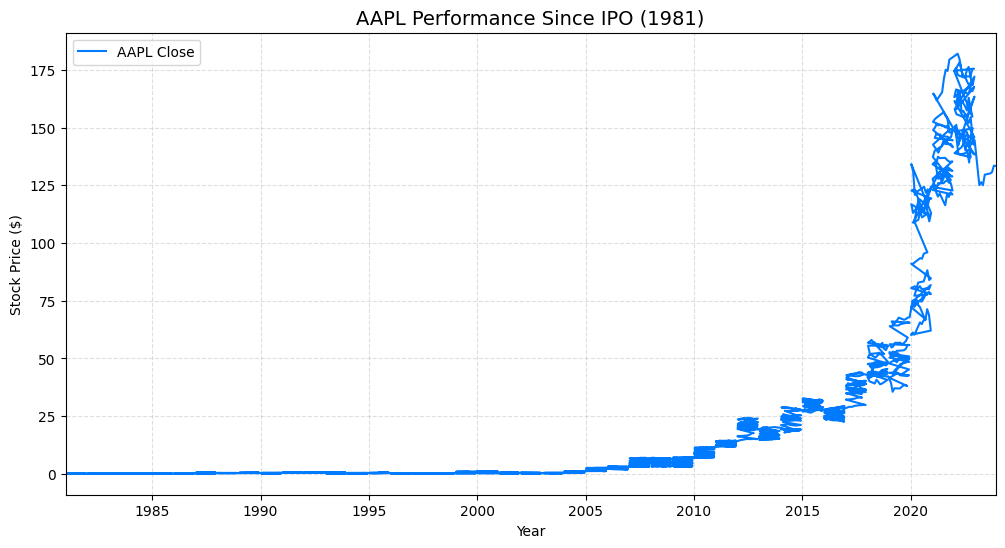

In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], color='#007AFF', label='AAPL Close')

# Get current axis
ax = plt.gca()

# 1. FORCE the start and end dates to match your data
# This removes the extra padding before 1981
ax.set_xlim(df.index.min(), df.index.max())

# 2. Set the 5-year interval ticks as before
ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xlabel('Year')
plt.ylabel('Stock Price ($)')
plt.title('AAPL Performance Since IPO (1981)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.show()

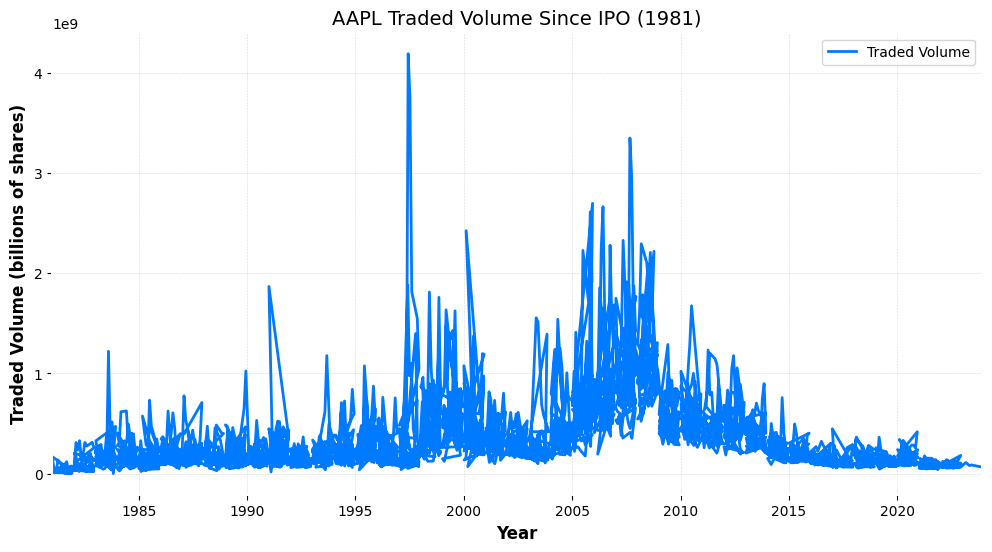

In [30]:
# The trend is of a relatively stable value through 2005, then an increase that accelerates through around 2023, and then a sharp decrease.

# Data Visualization

#     Utilize Matplotlib to plot closing prices and traded volume over time.

## We've already plotted closing prices over time. Now let's plot traded volume over time:

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Volume'], color='#007AFF', label='Traded Volume')

# Get current axis
ax = plt.gca()

# 1. FORCE the start and end dates to match your data
# This removes the extra padding before 1981
ax.set_xlim(df.index.min(), df.index.max())

# 2. Set the 5-year interval ticks as before
ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xlabel('Year')
plt.ylabel('Traded Volume (billions of shares)')
plt.title('AAPL Traded Volume Since IPO (1981)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.show()

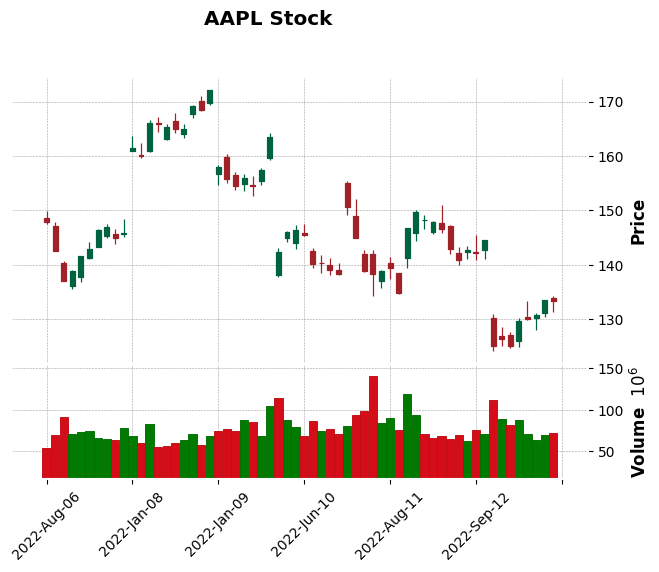

In [ ]:
#Traded volume has generally been stable, with a few high peaks over the years.
# Create a candlestick chart to depict high and low prices.
## A candlestick chart is really only readable for a smaller timeframe. Here is one for the last 60 days:
import mplfinance as mpf

# Simply pass the dataframe and the plot type
mpf.plot(df.tail(60), type='candle', style='charles', volume=True, title='AAPL Stock')

In [ ]:
#This specific candlestick chart shows that fluctuation within days is generally not too large but can come together among several days into a greater trend of fluctuation.
# Statistical Analysis

#     Compute summary statistics (mean, median, standard deviation) for key columns.
#We have done this already, but here it is again (50% is the median):
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,4186.000000,4186.000000,4186.000000,4186.000000,4186.000000,4.186000e+03
mean,16.695478,16.882574,16.501288,16.698669,16.027362,3.267486e+08
std,35.509792,35.923506,35.078016,35.507968,35.187737,3.338102e+08
min,0.049665,0.049665,0.049107,0.049107,0.038213,0.000000e+00
25%,0.288085,0.298689,0.283482,0.290877,0.240951,1.227044e+08
50%,0.488839,0.496362,0.482143,0.488839,0.405753,2.146116e+08
75%,16.357143,16.491607,16.217321,16.347054,14.158201,4.023852e+08
max,182.630005,182.940002,179.119995,182.009995,180.959747,4.190480e+09


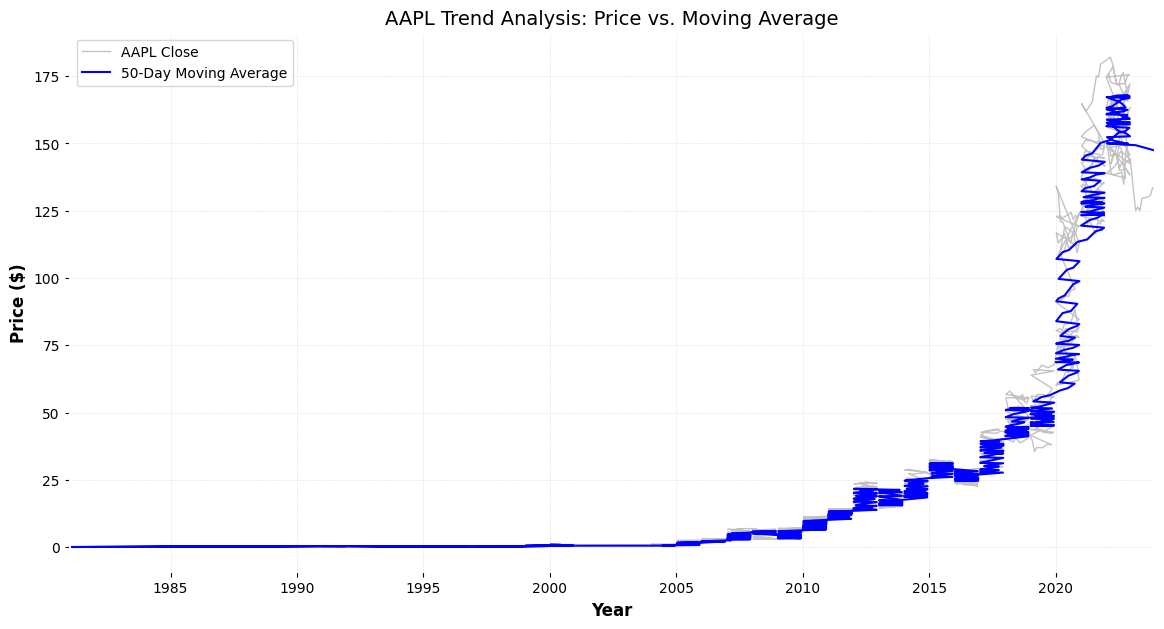

In [15]:
# Analyze closing prices with a moving average.
# So let's add a rolling average (50 days) to our data:
df['MA50'] = df['Close'].rolling(window=50).mean()
plt.figure(figsize=(14, 7))

# Plot the raw Closing Price (thin and slightly faded to highlight the averages)
plt.plot(df.index, df['Close'], label='AAPL Close', color='darkgray', alpha=0.7, linewidth=1)

# Plot the Moving Averages (thicker and bolder)
plt.plot(df.index, df['MA50'], label='50-Day Moving Average', color='blue', linewidth=1.5)
ax = plt.gca()
ax.set_xlim(df.index.min(), df.index.max()) # Keep our fixed 1981 start!
plt.title('AAPL Trend Analysis: Price vs. Moving Average', fontsize=14)
plt.ylabel('Price ($)')
plt.xlabel('Year')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:
# A 50-day moving average shows a smoother version of the closing price without some of the drastic increases and decreases at the end of the data.

# Hypothesis Testing

#     Execute a t-test to compare average closing prices across different years.
## We can compare the average price in 2022 vs. the average price in 2023.
from scipy.stats import ttest_ind

# Extract price samples for two specific years
prices_2022 = df.loc['2022', 'Close']
prices_2023 = df.loc['2023', 'Close']

# # Perform the Independent Samples t-test
t_stat, p_value = ttest_ind(prices_2022, prices_2023)

print(f"Mean Price (2022): ${prices_2022.mean():.2f}")
print(f"Mean Price (2023): ${prices_2023.mean():.2f}")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4e}")

if p_value < 0.05:
    print("There is a statistically significant difference in average price between the two years.")
else:
    print("There is not a statistically significant difference in average price between the two years.")

Mean Price (2022): $156.94
Mean Price (2023): $129.23
T-Statistic: 6.0403
P-Value: 2.3148e-08
There is a statistically significant difference in average price between the two years.


In [21]:
# Examine daily returns’ distribution and test for normality using SciPy.
# Calculate Daily Returns
df['Daily_Return'] = df['Close'].pct_change()

# Clean the data (remove the first NaN)
daily_returns = df['Daily_Return'].dropna()

print(f"Average Daily Return: {daily_returns.mean():.4%}")
print(f"Daily Volatility (Std Dev): {daily_returns.std():.4%}")

Average Daily Return: 0.2648%
Daily Volatility (Std Dev): 4.5110%


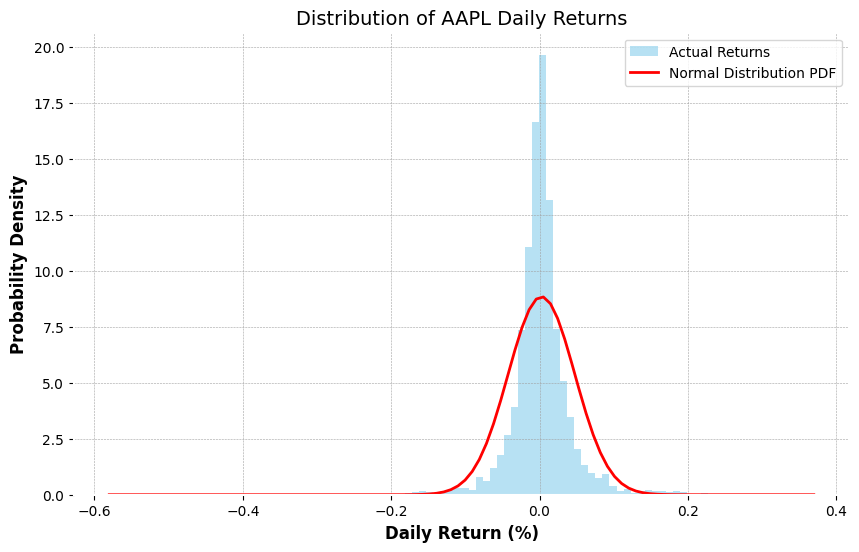

In [29]:
from scipy.stats import norm

plt.figure(figsize=(10, 6))

# Plot Histogram
plt.hist(daily_returns, bins=100, density=True, alpha=0.6, color='skyblue', label='Actual Returns')

# Overlay Normal Distribution Curve
mu, std = daily_returns.mean(), daily_returns.std()
x = np.linspace(daily_returns.min(), daily_returns.max(), 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'r', linewidth=2, label='Normal Distribution PDF')

plt.title('Distribution of AAPL Daily Returns', fontsize=14)
plt.xlabel('Daily Return (%)')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

In [28]:
from scipy.stats import normaltest

stat, p_value = normaltest(daily_returns)

print(f"Statistics: {stat:.4f}")
print(f"P-Value: {p_value:.4e}")

if p_value < 0.05:
    print("Result: Reject H0. The returns are NOT normally distributed.")
else:
    print("Result: Fail to reject H0. The returns appear normal.")

Statistics: 1100.3969
P-Value: 1.1268e-239
Result: Reject H0. The returns are NOT normally distributed.


# Summary and Insights
The general trend of AAPL stock is of a relatively stable value through 2005, then an increase that accelerates through around 2023, and then a sharp decrease.
Traded volume has generally been stable, with a few high peaks over the years.
A candlestick chart of the last 60 days shows that fluctuation within days is generally not too large but can come together among several days into a greater trend of fluctuation.
A 50-day moving average shows a smoother version of the closing price without some of the drastic increases and decreases at the end of the data.
A t-test comparing average closing prices between 2022 and 2023 showed that there was a statistically significant difference in average price between the two years. This conforms with the intuition one would have from looking at the data.
Finally, examining daily returns’ distribution shows that the returns are distributed relatively evenly around a mean close to zero, but comparing to a normal distribution curve and testing for normality using SciPy shows they are not normally distributed.


# Reflection
Challenges and Solutions
This dataset provided some challenges. One challenge was cleaning the data and removing lines with erroneous date lines (such as zeros) that caused problems with the chart. I was able to solve this by filtering out lines with values of NaN, zero, or less than the ealiest value (1981-1-1). Other challenges involved formatting the charts so that they could be viewed appropriately. For example, I set chart labels to only show every 5 years.